In [162]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [164]:
data=pd.read_csv("/Users/aja/Desktop/uni/datagath/user_behavior_dataset.csv")

In [166]:
data.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [168]:
data.tail()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
695,696,iPhone 12,iOS,92,3.9,1082,26,381,22,Male,2
696,697,Xiaomi Mi 11,Android,316,6.8,1965,68,1201,59,Male,4
697,698,Google Pixel 5,Android,99,3.1,942,22,457,50,Female,2
698,699,Samsung Galaxy S21,Android,62,1.7,431,13,224,44,Male,1
699,700,OnePlus 9,Android,212,5.4,1306,49,828,23,Female,3


In [170]:
data.columns

Index(['User ID', 'Device Model', 'Operating System',
       'App Usage Time (min/day)', 'Screen On Time (hours/day)',
       'Battery Drain (mAh/day)', 'Number of Apps Installed',
       'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class'],
      dtype='object')

In [172]:
mean_value = data['Screen On Time (hours/day)'].mean()
mean_value

5.272714285714286

In [174]:
min_value=data['Age'].min()
min_value


18

In [176]:
max_value=data['Age'].max()
max_value

59

In [182]:
app_usage=data['App Usage Time (min/day)'].mean()
app_usage

271.12857142857143

In [184]:
data_usage=data['Data Usage (MB/day)'].mean()
data_usage

929.7428571428571

In [186]:
num_apps_mean=data['Number of Apps Installed'].mean()
num_apps_mean

50.68142857142857

In [188]:
num_apps_max=data['Number of Apps Installed'].max()
num_apps_max

99

In [190]:
num_apps_min=data['Number of Apps Installed'].min()
num_apps_min

10

In [192]:
heavy_users = data[data['Screen On Time (hours/day)'] > mean_value]
heavy_users

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
6,7,Samsung Galaxy S21,Android,350,7.3,1802,66,1054,21,Female,4
7,8,OnePlus 9,Android,543,11.4,2956,82,1702,31,Male,5
8,9,Samsung Galaxy S21,Android,340,7.7,2138,75,1053,42,Female,4
9,10,iPhone 12,iOS,424,6.6,1957,75,1301,42,Male,4
...,...,...,...,...,...,...,...,...,...,...,...
692,693,Xiaomi Mi 11,Android,378,6.7,1898,78,1455,48,Female,4
693,694,Xiaomi Mi 11,Android,505,8.6,2792,82,1709,31,Male,5
694,695,Samsung Galaxy S21,Android,564,9.7,2422,83,1985,34,Female,5
696,697,Xiaomi Mi 11,Android,316,6.8,1965,68,1201,59,Male,4


In [194]:
data=data.drop(['User Behavior Class'],axis=1)


In [196]:
data.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female


In [198]:
data['Device Model'].unique()

array(['Google Pixel 5', 'OnePlus 9', 'Xiaomi Mi 11', 'iPhone 12',
       'Samsung Galaxy S21'], dtype=object)

In [200]:
data.nunique()

User ID                       700
Device Model                    5
Operating System                2
App Usage Time (min/day)      387
Screen On Time (hours/day)    108
Battery Drain (mAh/day)       628
Number of Apps Installed       86
Data Usage (MB/day)           585
Age                            42
Gender                          2
dtype: int64

<Axes: >

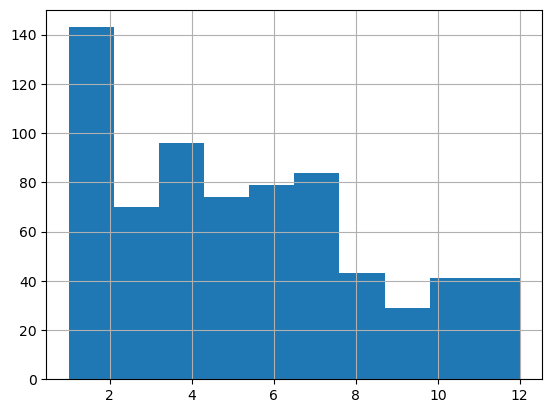

In [202]:
data['Screen On Time (hours/day)'].hist()

<Axes: xlabel='Age'>

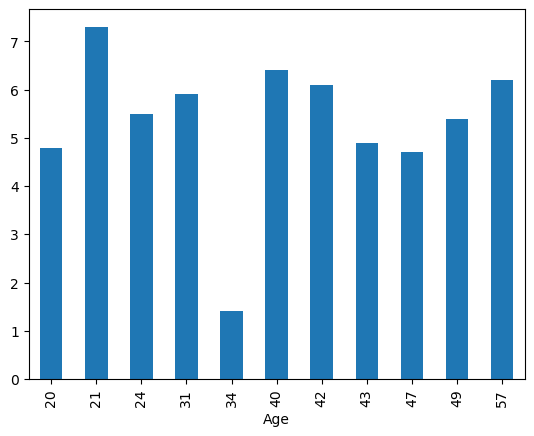

In [204]:
data_subset=data.head(15)
data_subset.groupby('Age')['Screen On Time (hours/day)'].mean().plot(kind='bar')


<Axes: xlabel='Device Model'>

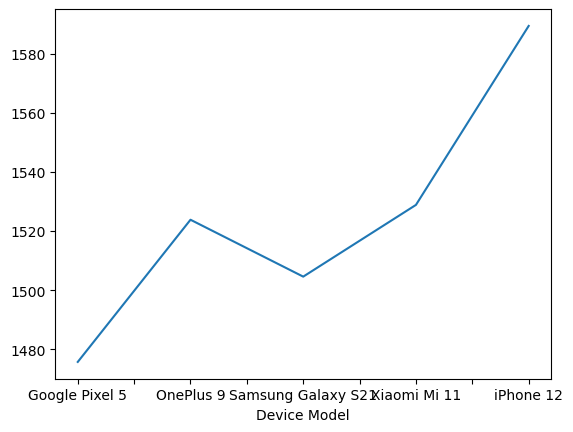

In [206]:
data.groupby('Device Model')['Battery Drain (mAh/day)'].mean().plot(kind='line')


In [208]:
# Grouping data by Device Type
avg_battery_by_device = data.groupby('Device Model')['Battery Drain (mAh/day)'].mean()
print(avg_battery_by_device)


Device Model
Google Pixel 5        1475.676056
OnePlus 9             1523.849624
Samsung Galaxy S21    1504.571429
Xiaomi Mi 11          1528.876712
iPhone 12             1589.513699
Name: Battery Drain (mAh/day), dtype: float64


In [210]:
#calculate battery drain per unit of usage 
data['Battery Efficiency'] = data['Battery Drain (mAh/day)'] / data['Screen On Time (hours/day)']
battery_efficiency=data['Battery Efficiency'].head(20)

<Axes: >

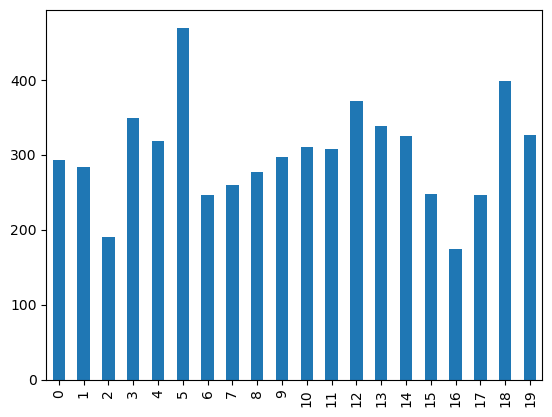

In [212]:
battery_efficiency.plot(kind='bar')


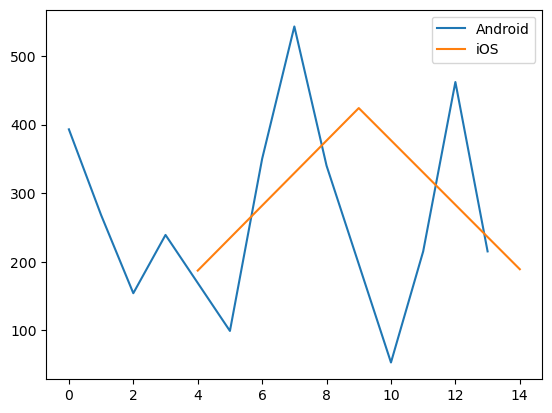

In [214]:
data_subset.groupby('Operating System')['App Usage Time (min/day)'].plot(kind='line')
plt.legend()

<Axes: >

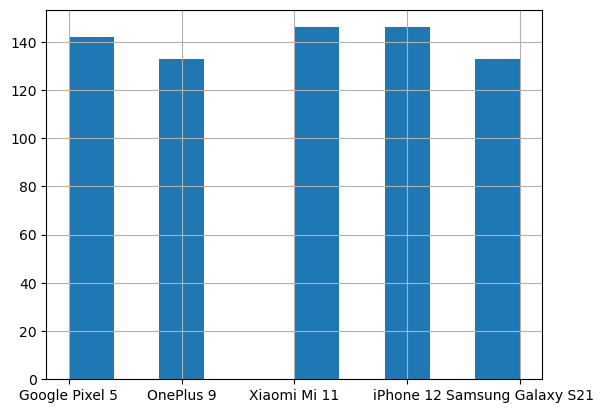

In [216]:
data['Device Model'].hist()

<Axes: xlabel='Data Usage (MB/day)'>

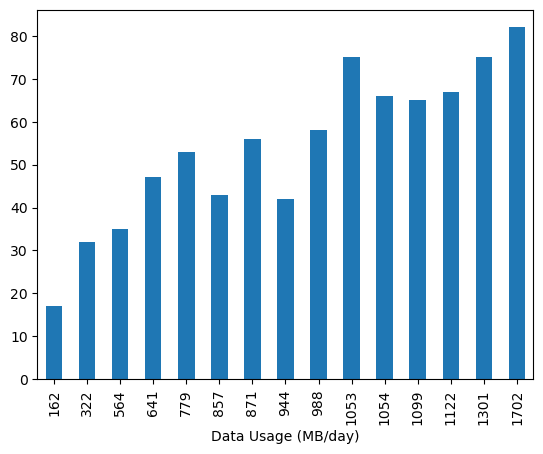

In [106]:
data_subset.groupby('Data Usage (MB/day)')['Number of Apps Installed'].mean().plot(kind='bar')

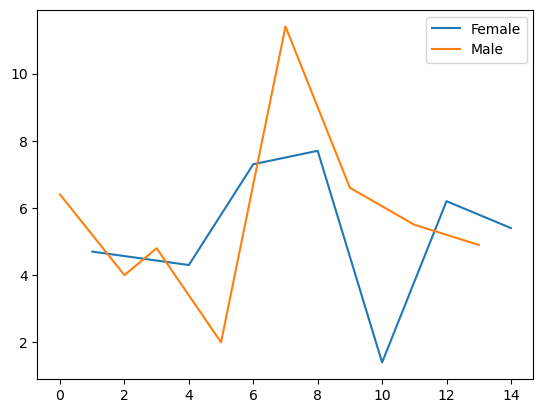

In [112]:
data_subset.groupby('Gender')['Screen On Time (hours/day)'].plot(kind='line')
plt.legend()